In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random

In [2]:
df = pd.read_csv("../01-intro/car_fuel_efficiency.cv")

In [3]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [4]:
df = df[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

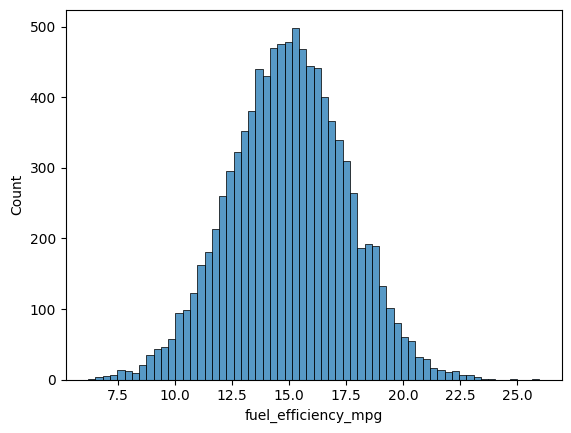

In [5]:
sns.histplot(df['fuel_efficiency_mpg'])

Q1. Missing values column

In [6]:
df.isna().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

The answer is 'horsepower'

Q2. Median for horsepower

In [7]:
df['horsepower'].median()

np.float64(149.0)

The answer is 149

In [8]:
n = len(df)
n_val = int(n*0.2) #validation test length
n_test = int(n*0.2) #test set length
n_train = n - n_val - n_test
n

9704

In [9]:
idx = np.arange(n)
idx

array([   0,    1,    2, ..., 9701, 9702, 9703], shape=(9704,))

In [11]:
np.random.seed = 42
np.random.shuffle(idx)
idx

array([3829, 2542, 3204, ..., 9034, 4789,   13], shape=(9704,))

In [12]:
df_train = df.iloc[idx[:n_train]]
df_validation = df.iloc[idx[n_train: n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
3829,170,NaN,3191.732841,2015,15.523037
2542,140,89.0,3682.120553,2014,11.179959
3204,190,NaN,2782.489819,2006,15.735188
742,320,108.0,2754.579035,2015,15.433472
4525,190,123.0,3216.136021,2020,14.052835


Question 3. Missing values in 'horsepower'

First choice. Changing NaNs to 0s

In [13]:
df_train['horsepower'] = df_train['horsepower'].fillna(0)
df_train.isna().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [14]:
df_validation['horsepower'] = df_validation['horsepower'].fillna(0)
df_validation.isna().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [15]:
X = df_train[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']]
X = np.array(X)
y = df_train['fuel_efficiency_mpg']
X, y

(array([[ 170.        ,    0.        , 3191.7328414 , 2015.        ],
        [ 140.        ,   89.        , 3682.12055307, 2014.        ],
        [ 190.        ,    0.        , 2782.48981923, 2006.        ],
        ...,
        [ 190.        ,  173.        , 3315.83878943, 2016.        ],
        [ 160.        ,  158.        , 2503.19197848, 2008.        ],
        [ 270.        ,    0.        , 2708.23841968, 2015.        ]],
       shape=(5824, 4)),
 3829    15.523037
 2542    11.179959
 3204    15.735188
 742     15.433472
 4525    14.052835
           ...    
 4244    12.993641
 8834    16.033270
 3026    13.715145
 1287    18.106099
 3569    16.399096
 Name: fuel_efficiency_mpg, Length: 5824, dtype: float64)

In [12]:
def train_linreg(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    IXTX = np.linalg.inv(XTX) #inverse XTX
    w_full = IXTX.dot(X.T).dot(y) #weights
    return w_full[0], w_full[1:]

In [17]:
w0, w = train_linreg(X, y)
w0, w

(np.float64(27.067388642113215),
 array([ 0.00015515,  0.00358389, -0.00500556,  0.00119807]))

In [14]:
def rmse (y_train, y_pred):
    se = (y_train - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [19]:
X_val = df_validation[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']]
X_val = np.array(X_val)
y_val = df_validation['fuel_efficiency_mpg']
X_val, y_val

(array([[ 170.        ,  169.        , 3216.63102789, 2021.        ],
        [ 270.        ,  113.        , 2952.28007722, 2020.        ],
        [ 220.        ,  142.        , 2953.60891853, 2020.        ],
        ...,
        [ 180.        ,  159.        , 3386.39693852, 2019.        ],
        [ 130.        ,    0.        , 2708.56792653, 2022.        ],
        [ 270.        ,  175.        , 3724.17058119, 2021.        ]],
       shape=(1940, 4)),
 8741    13.852814
 1147    14.748943
 2955    15.870010
 805     14.270006
 7160    13.075311
           ...    
 7176    14.926173
 6564    15.589162
 3598    12.774653
 6240    16.393585
 6722    11.815561
 Name: fuel_efficiency_mpg, Length: 1940, dtype: float64)

In [98]:
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred) 

np.float64(0.511995363081794)

Second choice. Changing NaNs to means

In [112]:
df_train.isnull().sum()

engine_displacement      0
horsepower             428
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [113]:
df_train['horsepower'].mean()

np.float64(149.88213491475167)

In [120]:
horsemean = df_train['horsepower'].mean()
df_train['horsepower'] = df_train['horsepower'].fillna(horsemean)
df_train['horsepower']

8476    164.000000
8874    123.000000
8022    131.000000
4568    149.882135
4974    137.000000
           ...    
8034    125.000000
329     178.000000
3238    189.000000
1084    158.000000
5876    128.000000
Name: horsepower, Length: 5824, dtype: float64

In [20]:
X = df_train[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']]
X = np.array(X)
y = df_train['fuel_efficiency_mpg']
X, y

(array([[ 160.        ,  207.        , 3313.05261291, 2008.        ],
        [ 190.        ,    0.        , 3020.30490862, 2005.        ],
        [ 220.        ,  145.        , 3981.61169938, 2002.        ],
        ...,
        [ 140.        ,  189.        , 1987.64593471, 2009.        ],
        [ 270.        ,  128.        , 3674.07421994, 2000.        ],
        [ 200.        ,   97.        , 2605.00418844, 2021.        ]],
       shape=(5824, 4)),
 371     13.598703
 4330    15.431035
 9416     9.986241
 868     14.323604
 1285    16.325075
           ...    
 7831    13.165980
 8003    17.544590
 1118    20.057794
 8333    12.523509
 3949    16.122192
 Name: fuel_efficiency_mpg, Length: 5824, dtype: float64)

In [122]:
def train_linreg(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    IXTX = np.linalg.inv(XTX) #inverse XTX
    w_full = IXTX.dot(X.T).dot(y) #weights
    return w_full[0], w_full[1:]

In [125]:
horsemeanval = df_validation['horsepower'].mean()
df_validation['horsepower'] = df_validation['horsepower'].fillna(horsemeanval)

np.int64(0)

In [29]:
X_val = df_validation[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']]
X_val = np.array(X_val)
y_val = df_validation['fuel_efficiency_mpg']
X_val, y_val

(array([[ 170.        ,  175.        , 2797.21534263, 2017.        ],
        [ 150.        ,  136.        , 3491.40124675, 2007.        ],
        [ 150.        ,  203.        , 3497.71476292, 2021.        ],
        ...,
        [ 170.        ,  118.        , 3309.9514506 , 2022.        ],
        [ 320.        ,  166.        , 3559.47955461, 2019.        ],
        [ 210.        ,  141.        , 3631.28873212, 2010.        ]],
       shape=(1940, 4)),
 2842    14.970573
 7060    12.202589
 1860    13.555717
 8007    14.608277
 6207    14.123108
           ...    
 1311    14.131719
 4360    14.506773
 7137    13.685757
 1613    12.076745
 3402    12.045200
 Name: fuel_efficiency_mpg, Length: 1940, dtype: float64)

In [127]:
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred) 

np.float64(0.5018004229402785)

Answer to Q3: with mean gives less rmse than with 0s

Question 4

In [32]:
df_train['horsepower'] = df_train['horsepower'].fillna(0)
df_train.isna().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [33]:
df_validation['horsepower'] = df_validation['horsepower'].fillna(0)
df_validation.isna().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [17]:
r = [0, 0.01, 0.1, 1, 5, 10, 100]

In [37]:
def train_linreg_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    IXTX = np.linalg.inv(XTX) #inverse XTX
    w_full = IXTX.dot(X.T).dot(y) #weights
    return w_full[0], w_full[1:]

In [35]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linreg_reg(X, y, r = r)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred) 

    print(r, w0, score)

0 29.746988513892585 0.5275162613219297
0.01 25.699603933431774 0.5269162713385362
0.1 11.55276004002761 0.5274621441936801
1 1.776071038897669 0.5302325056209664
5 0.3730376785230745 0.5307888935189429
10 0.18769933169417044 0.530865350290809
100 0.018883701548617605 0.5309355980393468


0.01 is the best

Q5. Seeds

In [ ]:
def eval_diff_seeds(idx):
    scores = []
    for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:

        n = len(df)
        n_val = int(0.2 * n)
        n_test = int(0.2 * n)
        n_train = n - (n_val + n_test)
        
        idx = np.arange(n)
        np.random.seed(i)
        np.random.shuffle(idx)
        
        df_train = df.iloc[idx[:n_train]]
        df_validation = df.iloc[idx[n_train: n_train + n_val]]
        df_test = df.iloc[idx[n_train + n_val:]]

        df_train['horsepower'] = df_train['horsepower'].fillna(0)
        df_validation['horsepower'] = df_validation['horsepower'].fillna(0)

        X = df_train[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']]
        X = np.array(X)
        y = df_train['fuel_efficiency_mpg']

        X_val = df_validation[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']]
        X_val = np.array(X_val)
        y_val = df_validation['fuel_efficiency_mpg']

        w0, w = train_linreg(X, y)
        y_pred = w0 + X_val.dot(w)

        score = rmse(y_val, y_pred) 

        scores.append(score)
    return scores


In [29]:
seeds = eval_diff_seeds(idx)
sd = np.std(seeds)
sd

np.float64(0.006989446426433706)

The answer to Q5 = 0.006

Q6. Combining train & validation sets

In [38]:
n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_validation = df.iloc[idx[n_train: n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
df_comb = pd.concat([df_train, df_validation])

df_comb['horsepower'] = df_comb['horsepower'].fillna(0)
df_test['horsepower'] = df_test['horsepower'].fillna(0)

X = df_comb[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']]
X = np.array(X)
y = df_comb['fuel_efficiency_mpg']

X_test = df_test[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']]
X_test = np.array(X_test)
y_test = df_test['fuel_efficiency_mpg']

r = 0.001

w0, w = train_linreg_reg(X, y, r)
y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)
score

np.float64(0.5156261299169602)

Q6 answer is 0.515